In [23]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [25]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [26]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [27]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [28]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [29]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
df.shape

(9568, 5)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [33]:
import torch
import torch.nn as nn

In [34]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [35]:
type(X_train_scaled)

numpy.ndarray

In [36]:
type(y_train)
y_train.shape

(7654,)

In [37]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [52]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


### Deep Learning

In [53]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()


        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
            
        )


    def forward(self, x):
        return self.model(x)
       

In [54]:
import torch.optim as optim

model = ANN()

#loss optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [57]:
# Train the ANN
# Train the ANN
train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader :
        optimizer.zero_grad()

        output = model(xb)
        loss = crietrion(output, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(test_loader)
    train_losses.append(epoch_train_loss)

    #Validation

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

    

epoch 1/100 ==> train loss = 802861.4817708334 & val loss = 193251.421875
epoch 2/100 ==> train loss = 717473.5166666667 & val loss = 161806.0
epoch 3/100 ==> train loss = 555985.70703125 & val loss = 114853.15625
epoch 4/100 ==> train loss = 363762.0240234375 & val loss = 69373.140625
epoch 5/100 ==> train loss = 211107.69095052083 & val loss = 40155.890625
epoch 6/100 ==> train loss = 128529.13404947917 & val loss = 26533.333984375
epoch 7/100 ==> train loss = 91245.54440104167 & val loss = 20030.958984375
epoch 8/100 ==> train loss = 71650.84609375 & val loss = 16060.265625
epoch 9/100 ==> train loss = 57830.15128580729 & val loss = 12891.326171875
epoch 10/100 ==> train loss = 46179.52720540365 & val loss = 10106.8115234375
epoch 11/100 ==> train loss = 35622.527986653644 & val loss = 7755.099609375
epoch 12/100 ==> train loss = 27089.871516927084 & val loss = 5892.42822265625
epoch 13/100 ==> train loss = 20440.054911295574 & val loss = 4424.31982421875
epoch 14/100 ==> train loss

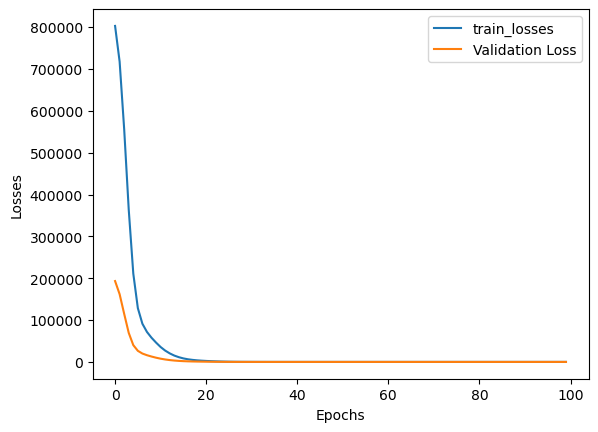

In [62]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame(
   {
       "Training_Loss": train_losses,
"Validation Loss": val_losses
       
   } 
)

plt.plot(loss_df["Training_Loss"], label = "train_losses")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [63]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>